In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import cv2
import numpy as np
from tqdm import tqdm

INPUT_BASE = "/content/drive/MyDrive/paperproject/data"
OUTPUT_BASE = "/content/drive/MyDrive/paperproject/preprocessed"

classes = ["cystic_hygroma", "normal"]

def extract_roi(gray):
    _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) == 0:
        return gray
    largest = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest)
    return gray[y:y+h, x:x+w]

def apply_clahe(gray):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(gray)

def preprocess_image(path):
    image = cv2.imread(path)
    if image is None:
        return None

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = extract_roi(gray)
    gray = apply_clahe(gray)
    gray = cv2.resize(gray, (256,256))

    return gray

for cls in classes:
    input_dir = os.path.join(INPUT_BASE, cls)
    output_dir = os.path.join(OUTPUT_BASE, cls)
    os.makedirs(output_dir, exist_ok=True)

    files = [f for f in os.listdir(input_dir) if f.endswith(('.png','.jpg','.jpeg'))]

    print(f"{cls}: {len(files)} images")

    for f in tqdm(files):
        img = preprocess_image(os.path.join(input_dir,f))
        if img is not None:
            cv2.imwrite(os.path.join(output_dir,f), img)

print("✅ PREPROCESS DONE")

cystic_hygroma: 235 images


100%|██████████| 235/235 [00:09<00:00, 25.46it/s]


normal: 458 images


100%|██████████| 458/458 [00:18<00:00, 24.15it/s]

✅ PREPROCESS DONE


In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sugiitamanivannan","key":"3740da50c3f567f2040b33d32cb51df2"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!kaggle datasets download -d aryashah2k/breast-ultrasound-images-dataset
!unzip breast-ultrasound-images-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/aryashah2k/breast-ultrasound-images-dataset
License(s): CC0-1.0
100% 195M/195M [00:01<00:00, 160MB/s]

Archive:  breast-ultrasound-images-dataset.zip
  inflating: Dataset_BUSI_with_GT/benign/benign (1).png  
  inflating: Dataset_BUSI_with_GT/benign/benign (1)_mask.png  
  inflating: Dataset_BUSI_with_GT/benign/benign (10).png  
  inflating: Dataset_BUSI_with_GT/benign/benign (10)_mask.png  
  inflating: Dataset_BUSI_with_GT/benign/benign (100).png  
  inflating: Dataset_BUSI_with_GT/benign/benign (100)_mask.png  
  inflating: Dataset_BUSI_with_GT/benign/benign (100)_mask_1.png  
  inflating: Dataset_BUSI_with_GT/benign/benign (101).png  
  inflating: Dataset_BUSI_with_GT/benign/benign (101)_mask.png  
  inflating: Dataset_BUSI_with_GT/benign/benign (102).png  
  inflating: Dataset_BUSI_with_GT/benign/benign (102)_mask.png  
  inflating: Dataset_BUSI_with_GT/benign/benign (103).png  
  inflating: Dataset_BUSI_with_GT/benign/benign (103)_mask.

In [6]:
import os, shutil

SRC = "/content/Dataset_BUSI_with_GT"
DEST = "/content/drive/MyDrive/paperproject/busi"

classes = ["benign", "malignant", "normal"]

for cls in classes:
    os.makedirs(os.path.join(DEST, cls), exist_ok=True)

    for file in os.listdir(os.path.join(SRC, cls)):
        if file.endswith(".png") and "_mask" not in file:   # IMPORTANT FILTER
            shutil.copy(
                os.path.join(SRC, cls, file),
                os.path.join(DEST, cls, file)
            )

print("✅ BUSI moved to Drive (without masks)")

✅ BUSI moved to Drive (without masks)


In [7]:
import torch
import torch.nn as nn
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader

BUSI_PATH = "/content/drive/MyDrive/paperproject/busi"

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(BUSI_PATH, transform=transform)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

model = models.resnet50(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 3)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

for epoch in range(10):
    model.train()
    total_loss = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)

        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

torch.save(model.state_dict(), "/content/drive/MyDrive/paperproject/resnet_busi.pth")

print("✅ BUSI TRAINING COMPLETE")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 149MB/s]


Epoch 1, Loss: 31.6895
Epoch 2, Loss: 8.8958
Epoch 3, Loss: 4.1329
Epoch 4, Loss: 4.0340
Epoch 5, Loss: 3.6353
Epoch 6, Loss: 1.4727
Epoch 7, Loss: 2.2493
Epoch 8, Loss: 4.5680
Epoch 9, Loss: 4.3773
Epoch 10, Loss: 4.5151
✅ BUSI TRAINING COMPLETE


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

===== FOLD 1 =====


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet169_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet169_Weights.DEFAULT` to get the most up-to-dat

Downloading: "https://download.pytorch.org/models/densenet169-b2777c0a.pth" to /root/.cache/torch/hub/checkpoints/densenet169-b2777c0a.pth


100%|██████████| 54.7M/54.7M [00:00<00:00, 123MB/s]


Epoch [1/1000] Train Loss=0.2903 Train Acc=0.8998
Val Loss=0.3251 Val Acc=0.9023
Epoch [2/1000] Train Loss=0.1096 Train Acc=0.9653
Val Loss=0.1300 Val Acc=0.9368
Epoch [3/1000] Train Loss=0.0654 Train Acc=0.9750
Val Loss=0.2007 Val Acc=0.9425
Epoch [4/1000] Train Loss=0.0350 Train Acc=0.9923
Val Loss=0.1449 Val Acc=0.9483
Epoch [5/1000] Train Loss=0.0234 Train Acc=0.9961
Val Loss=0.1689 Val Acc=0.9540
Epoch [6/1000] Train Loss=0.0145 Train Acc=0.9942
Val Loss=0.1504 Val Acc=0.9425
Epoch [7/1000] Train Loss=0.0098 Train Acc=0.9981
Val Loss=0.1668 Val Acc=0.9540
Epoch [8/1000] Train Loss=0.0062 Train Acc=0.9981
Val Loss=0.2088 Val Acc=0.9483
Epoch [9/1000] Train Loss=0.0073 Train Acc=0.9961
Val Loss=0.2188 Val Acc=0.9425
Epoch [10/1000] Train Loss=0.0096 Train Acc=0.9961
Val Loss=0.2329 Val Acc=0.9540
Epoch [11/1000] Train Loss=0.0096 Train Acc=0.9961
Val Loss=0.2201 Val Acc=0.9368
Epoch [12/1000] Train Loss=0.0503 Train Acc=0.9846
Val Loss=0.2645 Val Acc=0.9310
Epoch [13/1000] Train Los

...

Epoch [1/1000] Train Loss=0.3094 Train Acc=0.8923
Val Loss=0.1942 Val Acc=0.9538
Epoch [2/1000] Train Loss=0.0784 Train Acc=0.9788
Val Loss=0.2067 Val Acc=0.9595
Epoch [3/1000] Train Loss=0.0652 Train Acc=0.9788
Val Loss=0.2573 Val Acc=0.9422
Epoch [4/1000] Train Loss=0.0468 Train Acc=0.9904
Val Loss=0.1887 Val Acc=0.9595
Epoch [5/1000] Train Loss=0.0379 Train Acc=0.9885
Val Loss=0.1864 Val Acc=0.9653
Epoch [6/1000] Train Loss=0.0249 Train Acc=0.9962
Val Loss=0.2127 Val Acc=0.9595
Epoch [7/1000] Train Loss=0.0128 Train Acc=0.9962
Val Loss=0.1549 Val Acc=0.9595
Epoch [8/1000] Train Loss=0.0118 Train Acc=0.9981
Val Loss=0.1928 Val Acc=0.9595
Epoch [9/1000] Train Loss=0.0115 Train Acc=0.9962
Val Loss=0.1940 Val Acc=0.9595
Epoch [10/1000] Train Loss=0.0081 Train Acc=0.9981
Val Loss=0.2323 Val Acc=0.9653
Epoch [11/1000] Train Loss=0.0300 Train Acc=0.9885
Val Loss=0.1699 Val Acc=0.9538
Epoch [12/1000] Train Loss=0.0342 Train Acc=0.9885
Val Loss=0.2333 Val Acc=0.9538
Epoch [13/1000] Train Los

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet169_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet169_Weights.DEFAULT` to get the most up-to-dat

Epoch [1/1000] Train Loss=0.2981 Train Acc=0.9058
Val Loss=0.2196 Val Acc=0.9480
Epoch [2/1000] Train Loss=0.0986 Train Acc=0.9712
Val Loss=0.1498 Val Acc=0.9538
Epoch [3/1000] Train Loss=0.0613 Train Acc=0.9846
Val Loss=0.1786 Val Acc=0.9480
Epoch [4/1000] Train Loss=0.0442 Train Acc=0.9827
Val Loss=0.1561 Val Acc=0.9422
Epoch [5/1000] Train Loss=0.0397 Train Acc=0.9923
Val Loss=0.1658 Val Acc=0.9480
Epoch [6/1000] Train Loss=0.0118 Train Acc=0.9981
Val Loss=0.1937 Val Acc=0.9422
Epoch [7/1000] Train Loss=0.0115 Train Acc=0.9962
Val Loss=0.2361 Val Acc=0.9422
Epoch [8/1000] Train Loss=0.0520 Train Acc=0.9788
Val Loss=0.1840 Val Acc=0.9306
Epoch [9/1000] Train Loss=0.0453 Train Acc=0.9865
Val Loss=0.2066 Val Acc=0.9422
Epoch [10/1000] Train Loss=0.0432 Train Acc=0.9788
Val Loss=0.1182 Val Acc=0.9595
Epoch [11/1000] Train Loss=0.0224 Train Acc=0.9923
Val Loss=0.1578 Val Acc=0.9595
Epoch [12/1000] Train Loss=0.0093 Train Acc=0.9962
Val Loss=0.1747 Val Acc=0.9538
Epoch [13/1000] Train Los

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet169_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet169_Weights.DEFAULT` to get the most up-to-dat

Epoch [1/1000] Train Loss=0.3500 Train Acc=0.8865
Val Loss=0.1771 Val Acc=0.9422
Epoch [2/1000] Train Loss=0.1259 Train Acc=0.9538
Val Loss=0.1691 Val Acc=0.9595
Epoch [3/1000] Train Loss=0.0379 Train Acc=0.9923
Val Loss=0.1581 Val Acc=0.9480
Epoch [4/1000] Train Loss=0.0230 Train Acc=0.9942
Val Loss=0.1919 Val Acc=0.9538
Epoch [5/1000] Train Loss=0.0252 Train Acc=0.9942
Val Loss=0.1785 Val Acc=0.9422
Epoch [6/1000] Train Loss=0.0370 Train Acc=0.9885
Val Loss=0.1497 Val Acc=0.9595
Epoch [7/1000] Train Loss=0.0566 Train Acc=0.9846
Val Loss=0.2515 Val Acc=0.9480
Epoch [8/1000] Train Loss=0.0460 Train Acc=0.9885
Val Loss=0.2221 Val Acc=0.9538
Epoch [9/1000] Train Loss=0.0375 Train Acc=0.9942
Val Loss=0.1624 Val Acc=0.9480
Epoch [10/1000] Train Loss=0.0127 Train Acc=0.9962
Val Loss=0.1895 Val Acc=0.9480
Epoch [11/1000] Train Loss=0.0049 Train Acc=1.0000
Val Loss=0.2019 Val Acc=0.9538
Epoch [12/1000] Train Loss=0.0447 Train Acc=0.9865
Val Loss=0.2551 Val Acc=0.9364
Epoch [13/1000] Train Los

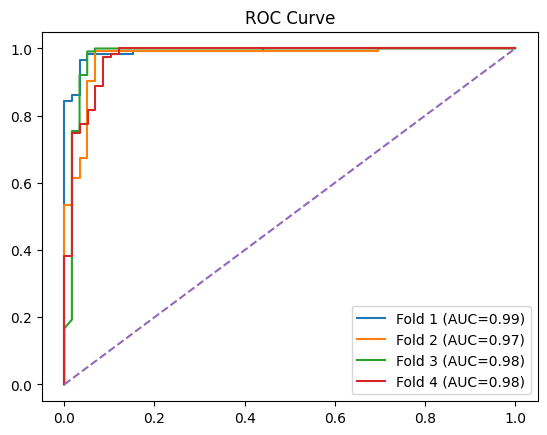

In [8]:
# ================================
# 1. SETUP
# ================================
from google.colab import drive
drive.mount('/content/drive')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_score, f1_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ================================
# 2. PATHS
# ================================
BASE = "/content/drive/MyDrive/paperproject"
DATA_PATH = BASE + "/preprocessed"
MODEL_PATH = BASE + "/models"
RESULT_PATH = BASE + "/results"
BUSI_WEIGHTS = BASE + "/resnet_busi.pth"

os.makedirs(MODEL_PATH, exist_ok=True)
os.makedirs(RESULT_PATH, exist_ok=True)

# ================================
# 3. DATASET
# ================================
transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(DATA_PATH, transform=transform)
targets = dataset.targets

# ================================
# 4. RESNET
# ================================
def get_resnet():
    model = models.resnet50(pretrained=True)
    model.fc = nn.Linear(model.fc.in_features, 3)
    model.load_state_dict(torch.load(BUSI_WEIGHTS))
    model.fc = nn.Linear(model.fc.in_features, 2)
    return model

# ================================
# 5. CBAM
# ================================
class CBAM(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.ca = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, channels//16, 1),
            nn.ReLU(),
            nn.Conv2d(channels//16, channels, 1),
            nn.Sigmoid()
        )
        self.sa = nn.Sequential(
            nn.Conv2d(2,1,7,padding=3),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x * self.ca(x)
        avg = torch.mean(x, dim=1, keepdim=True)
        max,_ = torch.max(x, dim=1, keepdim=True)
        x = x * self.sa(torch.cat([avg,max], dim=1))
        return x

# ================================
# 6. DENSENET
# ================================
class DenseNetCBAM(nn.Module):
    def __init__(self):
        super().__init__()
        self.base = models.densenet169(pretrained=True)
        self.cbam = CBAM(1664)
        self.fc = nn.Linear(1664, 2)

    def forward(self, x):
        x = self.base.features(x)
        x = self.cbam(x)
        x = F.relu(x)
        x = F.adaptive_avg_pool2d(x, (1,1))
        x = torch.flatten(x,1)
        return self.fc(x)

# ================================
# 7. METRICS
# ================================
def compute_metrics(y_true, y_pred, y_prob):
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()

    acc = (TP+TN)/(TP+TN+FP+FN)
    sens = TP/(TP+FN)
    spec = TN/(TN+FP)

    prec = precision_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    return acc, sens, spec, prec, f1, fpr, tpr, roc_auc, cm

# ================================
# 8. SAVE FUNCTIONS
# ================================
def save_cm(cm, fold):
    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix Fold {fold}")
    plt.savefig(f"{RESULT_PATH}/cm_fold{fold}.png")
    plt.close()

def save_loss(losses, fold):
    plt.figure()
    plt.plot(losses)
    plt.title(f"Loss Curve Fold {fold}")
    plt.savefig(f"{RESULT_PATH}/loss_fold{fold}.png")
    plt.close()
# ================================
# TRAIN / VAL CURVES
# ================================
def save_training_curves(
        train_losses,
        val_losses,
        train_accs,
        val_accs,
        fold):

    epochs = np.arange(1, len(train_losses)+1)

    train_losses_s = smooth_curve(train_losses)
    val_losses_s = smooth_curve(val_losses)

    train_accs_s = smooth_curve(train_accs)
    val_accs_s = smooth_curve(val_accs)

    marker_idx = np.arange(
        99,
        len(epochs),
        100
    )

    # LOSS CURVE
    plt.figure(figsize=(10,6))

    plt.plot(
        epochs,
        train_losses_s,
        label='Train Loss'
    )

    plt.plot(
        epochs,
        val_losses_s,
        label='Validation Loss'
    )

    plt.scatter(
        epochs[marker_idx],
        train_losses_s[marker_idx],
        s=40
    )

    plt.scatter(
        epochs[marker_idx],
        val_losses_s[marker_idx],
        s=40
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Loss Curve Fold {fold}")
    plt.legend()
    plt.grid(True)

    plt.savefig(
        f"{RESULT_PATH}/loss_curve_fold{fold}.png"
    )
    plt.close()

    # ACCURACY CURVE
    plt.figure(figsize=(10,6))

    plt.plot(
        epochs,
        train_accs_s,
        label='Train Accuracy'
    )

    plt.plot(
        epochs,
        val_accs_s,
        label='Validation Accuracy'
    )

    plt.scatter(
        epochs[marker_idx],
        train_accs_s[marker_idx],
        s=40
    )

    plt.scatter(
        epochs[marker_idx],
        val_accs_s[marker_idx],
        s=40
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Accuracy Curve Fold {fold}")
    plt.legend()
    plt.grid(True)

    plt.savefig(
        f"{RESULT_PATH}/accuracy_curve_fold{fold}.png"
    )
    plt.close()

# ================================
# SMOOTHING FUNCTION
# ================================
def smooth_curve(values, window=15):
    if len(values) < window:
        return values

    smoothed = np.convolve(
        values,
        np.ones(window)/window,
        mode='valid'
    )

    pad = [smoothed[0]]*(window-1)
    return np.concatenate([pad, smoothed])
# ================================
# 9. TRAINING
# ================================

def train_hybrid(epochs=1000, patience=25):

    skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    all_acc, all_sens, all_spec, all_prec, all_f1, all_auc = [],[],[],[],[],[]

    plt.figure()

    for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(targets)), targets)):
        print(f"\n===== FOLD {fold+1} =====")

        train_loader = DataLoader(Subset(dataset, train_idx), batch_size=16, shuffle=True)
        val_loader = DataLoader(Subset(dataset, val_idx), batch_size=16)

        resnet = get_resnet().to(device)
        densenet = DenseNetCBAM().to(device)

        optimizer = torch.optim.Adam(
            list(resnet.parameters()) + list(densenet.parameters()), lr=1e-4
        )

        criterion = nn.CrossEntropyLoss()

        best_acc = -1
        counter = 0
        train_losses = []
        val_losses = []
        train_accs = []
        val_accs = []

        for epoch in range(epochs):

            resnet.train()
            densenet.train()

            running_loss = 0
            train_correct = 0
            train_total = 0


            for x,y in train_loader:
                x,y = x.to(device), y.to(device)

                optimizer.zero_grad()
                out = (resnet(x)+densenet(x))/2
                loss = criterion(out,y)
                loss.backward()
                optimizer.step()
                preds = torch.argmax(out, dim=1)

                train_correct += (preds == y).sum().item()
                train_total += y.size(0)

                running_loss += loss.item()


            epoch_train_loss = running_loss / len(train_loader)
            epoch_train_acc = train_correct / train_total

            train_losses.append(epoch_train_loss)
            train_accs.append(epoch_train_acc)

            print(
                f"Epoch [{epoch+1}/{epochs}] "
                f"Train Loss={epoch_train_loss:.4f} "
                f"Train Acc={epoch_train_acc:.4f}"
)
            val_running_loss = 0
            # VALIDATION
            resnet.eval()
            densenet.eval()

            y_true,y_pred,y_prob = [],[],[]

            with torch.no_grad():
                for x,y in val_loader:
                    x = x.to(device)
                    out = (resnet(x)+densenet(x))/2

                    prob = torch.softmax(out,dim=1)[:,1]
                    pred = torch.argmax(out,dim=1)

                    y_true.extend(y.numpy())
                    y_pred.extend(pred.cpu().numpy())
                    y_prob.extend(prob.cpu().numpy())
                    loss = criterion(out, y.to(device))
                    val_running_loss += loss.item()

            acc,sens,spec,prec,f1,fpr,tpr,roc_auc,cm = compute_metrics(y_true,y_pred,y_prob)


            epoch_val_loss = val_running_loss / len(val_loader)

            val_losses.append(epoch_val_loss)
            val_accs.append(acc)

            if acc > best_acc:
                best_acc = acc
                best_metrics = (acc,sens,spec,prec,f1,roc_auc,fpr,tpr,cm)
                counter = 0

                torch.save(resnet.state_dict(), f"{MODEL_PATH}/resnet_fold{fold+1}.pth")
                torch.save(densenet.state_dict(), f"{MODEL_PATH}/densenet_fold{fold+1}.pth")

                save_cm(cm, fold+1)

            else:
                counter += 1
                if counter >= patience:
                    print("Early stopping")
                    break
            print(
                f"Val Loss={epoch_val_loss:.4f} "
                f"Val Acc={acc:.4f}"
)

        # USE BEST METRICS
        acc,sens,spec,prec,f1,roc_auc,fpr,tpr,cm = best_metrics

        all_acc.append(acc)
        all_sens.append(sens)
        all_spec.append(spec)
        all_prec.append(prec)
        all_f1.append(f1)
        all_auc.append(roc_auc)

        # SAVE METRICS
        with open(f"{RESULT_PATH}/metrics.txt","a") as f:
            f.write(f"\n===== Fold {fold+1} =====\n")
            f.write(f"Accuracy: {acc:.4f}\n")
            f.write(f"Sensitivity: {sens:.4f}\n")
            f.write(f"Specificity: {spec:.4f}\n")
            f.write(f"Precision: {prec:.4f}\n")
            f.write(f"F1 Score: {f1:.4f}\n")
            f.write(f"AUC: {roc_auc:.4f}\n")

        save_training_curves(
            train_losses,
            val_losses,
            train_accs,
            val_accs,
            fold+1
)

        plt.plot(fpr,tpr,label=f'Fold {fold+1} (AUC={roc_auc:.2f})')

    # ================================
    # FINAL STATS (MEAN ± STD)
    # ================================
    def summary(arr):
        return np.mean(arr), np.std(arr)

    with open(f"{RESULT_PATH}/metrics.txt","a") as f:
        f.write("\n===== FINAL RESULTS =====\n")
        for name,arr in zip(
            ["Accuracy","Sensitivity","Specificity","Precision","F1","AUC"],
            [all_acc,all_sens,all_spec,all_prec,all_f1,all_auc]
        ):
            mean,std = summary(arr)
            f.write(f"{name}: {mean:.4f} ± {std:.4f}\n")

    # ROC FINAL
    plt.plot([0,1],[0,1],'--')
    plt.legend()
    plt.title("ROC Curve")
    plt.savefig(f"{RESULT_PATH}/roc_curve.png")
    plt.show()

# ================================
# 10. RUN
# ================================
open(f"{RESULT_PATH}/metrics.txt", "w").close()
train_hybrid(epochs=1000, patience=25)

In [ ]:
+